# Chapter 61 — Batched Self-Attention

## Learning goals

By the end of this chapter, you should be able to:

- Interpret input shaped `[batch size, context length, embedding dimension]`.

- Project every position in every batch item into query, key, and value vectors.

- Explain why batched matrix multiplication never compares different batch items.

- Compute score tables shaped `[batch size, context length, context length]`.

- Broadcast one causal mask across the batch dimension.

- Apply softmax over source positions rather than over batches.

- Compute one output vector for every position in every batch item.

- Verify that a batched result equals separately computed single-sequence results.

- Detect causal-mask shapes that cannot broadcast correctly.

- Explain why changing one batch item cannot affect another item's attention output.


## The batch dimension

Chapter 60 used one sequence with shape `[context length, embedding dimension]`.

A **batch** groups several independent sequences so PyTorch can process them with the same operations.

Adding a leading batch dimension changes the input shape to `[batch size, context length, embedding dimension]`.

For an input shaped `[2, 3, 4]`, the dimensions mean:

- `2` independent sequences.

- `3` positions in each sequence.

- `4` features in each token-position vector.

> Batching evaluates several independent attention problems in parallel; it does not join the sequences into one longer sequence.


## A tiny batch

We use two three-token sequences with hand-written input vectors.

Dense tensors require the sequences in this toy batch to have the same context length.

Real batches often pad shorter sequences and use an additional padding mask, which is separate from the causal mask and is deferred to a later chapter.


In [1]:
import torch

device = "cpu"
batch_tokens = [
    ["the", "cat", "sat"],
    ["the", "dog", "ran"],
]

input_vectors = torch.tensor(
    [
        [
            [1.0, 0.0, 0.0, 0.5],
            [0.0, 1.0, 0.0, 0.5],
            [0.0, 0.0, 1.0, 0.5],
        ],
        [
            [1.0, 0.0, 0.0, 1.0],
            [0.0, 1.0, 1.0, 0.0],
            [0.5, 0.5, 0.0, 1.0],
        ],
    ],
    dtype=torch.float32,
    device=device,
)

batch_size, context_length, embedding_dimension = input_vectors.shape

print("device:", device)
print("input_vectors.shape:", input_vectors.shape)
print("batch | position | token | input vector")
print("-" * 61)
for batch_index, tokens in enumerate(batch_tokens):
    for position, token in enumerate(tokens):
        print(
            f"{batch_index:>5} | {position:>8} | {token:>5} | "
            f"{input_vectors[batch_index, position].tolist()}"
        )

device: cpu
input_vectors.shape: torch.Size([2, 3, 4])
batch | position | token | input vector
-------------------------------------------------------------
    0 |        0 |   the | [1.0, 0.0, 0.0, 0.5]
    0 |        1 |   cat | [0.0, 1.0, 0.0, 0.5]
    0 |        2 |   sat | [0.0, 0.0, 1.0, 0.5]
    1 |        0 |   the | [1.0, 0.0, 0.0, 1.0]
    1 |        1 |   dog | [0.0, 1.0, 1.0, 0.0]
    1 |        2 |   ran | [0.5, 0.5, 0.0, 1.0]


Indexing `input_vectors[0]` selects the complete first sequence, while `input_vectors[1]` selects the second.

The leading axis identifies independent examples and is not a token-position axis.


## Shared projections across the batch

The same projection matrices from Chapter 60 are applied to every position in every batch item.

Matrix multiplication treats the leading batch and context axes as groups of vectors and transforms only the final embedding axis.


In [2]:
query_projection_matrix = torch.tensor(
    [
        [1.0, 0.0],
        [0.0, 0.5],
        [0.0, 0.0],
        [0.5, 0.5],
    ],
    dtype=torch.float32,
    device=device,
)
key_projection_matrix = torch.tensor(
    [
        [1.0, 0.0],
        [0.0, 1.0],
        [0.0, 0.5],
        [0.5, 0.5],
    ],
    dtype=torch.float32,
    device=device,
)
value_projection_matrix = torch.tensor(
    [
        [0.5, 0.0],
        [0.0, 1.0],
        [1.0, 0.0],
        [0.0, 0.5],
    ],
    dtype=torch.float32,
    device=device,
)

query_vectors = input_vectors @ query_projection_matrix
key_vectors = input_vectors @ key_projection_matrix
value_vectors = input_vectors @ value_projection_matrix

print("input shape:", input_vectors.shape)
print("query shape:", query_vectors.shape)
print("key shape:", key_vectors.shape)
print("value shape:", value_vectors.shape)

input shape: torch.Size([2, 3, 4])
query shape: torch.Size([2, 3, 2])
key shape: torch.Size([2, 3, 2])
value shape: torch.Size([2, 3, 2])


The projections change the last dimension from embedding size `4` to projected size `2`.

They preserve the batch size and context length, so every projected tensor has shape `[2, 3, 2]`.


## One score table per sequence

Transposing the final two key dimensions changes `[batch, context, query-key features]` into `[batch, query-key features, context]`.

Batched matrix multiplication pairs operands that have the same batch index.

It therefore creates one square score table per sequence without a score between batch item `0` and batch item `1`.


In [3]:
transposed_key_vectors = key_vectors.transpose(-2, -1)
attention_scores = query_vectors @ transposed_key_vectors

print("query shape:", query_vectors.shape)
print("key shape:", key_vectors.shape)
print("transposed key shape:", transposed_key_vectors.shape)
print("score shape:", attention_scores.shape)
print("score table for batch item 0:")
print(attention_scores[0])
print("score table for batch item 1:")
print(attention_scores[1])

query shape: torch.Size([2, 3, 2])
key shape: torch.Size([2, 3, 2])
transposed key shape: torch.Size([2, 2, 3])
score shape: torch.Size([2, 3, 3])
score table for batch item 0:
tensor([[1.6250, 0.6250, 0.5000],
        [0.5000, 1.0000, 0.6250],
        [0.3750, 0.3750, 0.2500]])
score table for batch item 1:
tensor([[2.5000, 0.7500, 2.0000],
        [0.2500, 0.7500, 0.5000],
        [1.8750, 1.1250, 1.7500]])


The score tensor has shape `[batch size, receiving context, source context]`, or `[2, 3, 3]`.

Its first index selects a complete attention problem rather than participating in a dot product.


An explicit loop over batch items provides a direct check of this behavior.


In [4]:
separate_score_tables = []
for batch_index in range(batch_size):
    score_table = query_vectors[batch_index] @ key_vectors[batch_index].transpose(
        -2, -1
    )
    separate_score_tables.append(score_table)

stacked_score_tables = torch.stack(separate_score_tables, dim=0)

print("stacked score shape:", stacked_score_tables.shape)
print(
    "batched and separate scores match:",
    torch.allclose(attention_scores, stacked_score_tables),
)

stacked score shape: torch.Size([2, 3, 3])
batched and separate scores match: True


The equality confirms that the batched expression is a vectorized collection of independent score calculations.


## Broadcasting one causal mask

The causal rule depends on positions, not on which sequence occupies a batch slot.

A base mask therefore needs shape `[context length, context length]`, and adding a leading singleton dimension makes its batching intent explicit.

PyTorch aligns shapes from the right, so `[1, 3, 3]` can expand to `[2, 3, 3]`.


In [5]:
import math

query_key_dimension = query_vectors.shape[-1]
scaled_attention_scores = attention_scores / math.sqrt(query_key_dimension)

causal_mask = torch.tril(
    torch.ones(
        context_length,
        context_length,
        dtype=torch.bool,
        device=device,
    )
)
broadcastable_causal_mask = causal_mask.unsqueeze(dim=0)
expanded_causal_mask = broadcastable_causal_mask.expand_as(scaled_attention_scores)

masked_attention_scores = scaled_attention_scores.masked_fill(
    ~broadcastable_causal_mask,
    float("-inf"),
)

print("scores shape:", scaled_attention_scores.shape)
print("base mask shape:", causal_mask.shape)
print("broadcastable mask shape:", broadcastable_causal_mask.shape)
print("expanded mask shape:", expanded_causal_mask.shape)
print(
    "expanded masks are identical:",
    torch.equal(expanded_causal_mask[0], expanded_causal_mask[1]),
)
print("masked scores shape:", masked_attention_scores.shape)

scores shape: torch.Size([2, 3, 3])
base mask shape: torch.Size([3, 3])
broadcastable mask shape: torch.Size([1, 3, 3])
expanded mask shape: torch.Size([2, 3, 3])
expanded masks are identical: True
masked scores shape: torch.Size([2, 3, 3])


The explicit `expand_as` call is useful for inspection but unnecessary for `masked_fill`, which performs the broadcast itself.

Both batch items receive the same lower-triangular pattern while retaining their different score values.


## Softmax and batched outputs

The final score axis identifies source positions, so softmax still uses `dim=-1`.

It normalizes each receiving-position row independently inside each batch item.


In [6]:
attention_weights = torch.softmax(masked_attention_scores, dim=-1)
attention_output = attention_weights @ value_vectors
expanded_future_mask = (~broadcastable_causal_mask).expand_as(attention_weights)
future_weights = attention_weights[expanded_future_mask]

print("attention weight shape:", attention_weights.shape)
print("row sums:")
print(attention_weights.sum(dim=-1))
print("all future weights are zero:", end=" ")
print(torch.all(future_weights == 0.0).item())
print("attention output shape:", attention_output.shape)
print("attention output:")
print(attention_output)

attention weight shape: torch.Size([2, 3, 3])
row sums:
tensor([[1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000]])
all future weights are zero: True
attention output shape: torch.Size([2, 3, 2])
attention output:
tensor([[[0.5000, 0.2500],
         [0.2063, 0.8375],
         [0.4855, 0.5930]],

        [[0.5000, 0.5000],
         [0.7937, 0.7937],
         [0.5261, 0.8003]]])


The weights have shape `[batch, receiving context, source context]`, and every row sums to `1`.

Multiplying by values shaped `[batch, source context, value dimension]` removes the source axis and returns `[batch, receiving context, value dimension]`.

The output therefore contains one vector for every position in every sequence.


## A reusable batched function

The complete computation can be packaged in a typed function that returns the intermediate tensors needed for inspection.

Shape checks make the projection contract and the three-dimensional input requirement explicit.


In [7]:
def batched_causal_self_attention(
    input_vectors: torch.Tensor,
    query_projection_matrix: torch.Tensor,
    key_projection_matrix: torch.Tensor,
    value_projection_matrix: torch.Tensor,
) -> dict[str, torch.Tensor]:
    if input_vectors.ndim != 3:
        raise ValueError("input_vectors must have shape [batch, context, embedding].")

    input_dimension = input_vectors.shape[-1]
    for name, projection_matrix in {
        "query": query_projection_matrix,
        "key": key_projection_matrix,
        "value": value_projection_matrix,
    }.items():
        if projection_matrix.ndim != 2 or projection_matrix.shape[0] != input_dimension:
            raise ValueError(
                f"{name} projection must have shape [embedding, projected features]."
            )

    queries = input_vectors @ query_projection_matrix
    keys = input_vectors @ key_projection_matrix
    values = input_vectors @ value_projection_matrix
    if queries.shape[-1] != keys.shape[-1]:
        raise ValueError("query and key dimensions must match.")

    scores = queries @ keys.transpose(-2, -1)
    scores = scores / math.sqrt(queries.shape[-1])
    length = input_vectors.shape[-2]
    allowed = torch.tril(
        torch.ones(length, length, dtype=torch.bool, device=input_vectors.device)
    ).unsqueeze(dim=0)
    masked_scores = scores.masked_fill(~allowed, float("-inf"))
    weights = torch.softmax(masked_scores, dim=-1)
    output = weights @ values

    return {
        "queries": queries,
        "keys": keys,
        "values": values,
        "scores": scores,
        "masked_scores": masked_scores,
        "weights": weights,
        "output": output,
    }


batched_result = batched_causal_self_attention(
    input_vectors,
    query_projection_matrix,
    key_projection_matrix,
    value_projection_matrix,
)

for name, tensor in batched_result.items():
    print(name, tensor.shape)
print(
    "function output matches direct output:",
    torch.allclose(batched_result["output"], attention_output),
)

queries torch.Size([2, 3, 2])
keys torch.Size([2, 3, 2])
values torch.Size([2, 3, 2])
scores torch.Size([2, 3, 3])
masked_scores torch.Size([2, 3, 3])
weights torch.Size([2, 3, 3])
output torch.Size([2, 3, 2])
function output matches direct output: True


The function reproduces the direct calculation and keeps all intermediate batch dimensions visible.

A trainable module can use the same operations because `Linear`, batched matrix multiplication, masking, and softmax all preserve leading batch dimensions.


## Batched and separate calculations agree

Calling the same function on each sequence separately would violate its three-dimensional input contract.

Keeping a singleton batch dimension with the slice `batch_index : batch_index + 1` lets us compute each sequence independently and stack the results.


In [8]:
separate_outputs = []
for batch_index in range(batch_size):
    one_item_input = input_vectors[batch_index : batch_index + 1]
    one_item_result = batched_causal_self_attention(
        one_item_input,
        query_projection_matrix,
        key_projection_matrix,
        value_projection_matrix,
    )
    separate_outputs.append(one_item_result["output"].squeeze(dim=0))

stacked_separate_outputs = torch.stack(separate_outputs, dim=0)

print("batched output shape:", batched_result["output"].shape)
print("stacked separate output shape:", stacked_separate_outputs.shape)
print(
    "batched and separate outputs match:",
    torch.allclose(batched_result["output"], stacked_separate_outputs),
)

batched output shape: torch.Size([2, 3, 2])
stacked separate output shape: torch.Size([2, 3, 2])
batched and separate outputs match: True


The equality shows that batching changes how the calculations are organized, not the attention result for an individual sequence.


## Batch items remain independent

A stronger test changes only the second input sequence and recomputes the batch.

If attention never crosses the batch axis, the first sequence's output must remain unchanged.


In [9]:
changed_input_vectors = input_vectors.clone()
changed_input_vectors[1] = changed_input_vectors[1] + 10.0
changed_result = batched_causal_self_attention(
    changed_input_vectors,
    query_projection_matrix,
    key_projection_matrix,
    value_projection_matrix,
)

first_output_unchanged = torch.allclose(
    batched_result["output"][0],
    changed_result["output"][0],
)
second_output_changed = not torch.allclose(
    batched_result["output"][1],
    changed_result["output"][1],
)

print("first batch item output unchanged:", first_output_unchanged)
print("second batch item output changed:", second_output_changed)

first batch item output unchanged: True
second batch item output changed: True


Only the modified sequence changes.

This verifies behaviorally that neither projections nor attention matrix multiplication mix information across batch items.


## Catching mask-shape mistakes

Broadcasting aligns dimensions from right to left.

For scores shaped `[2, 3, 3]`, a mask shaped `[1, 3, 3]` aligns batch, receiving, and source axes correctly.

A mask shaped `[3, 3, 1]` puts the singleton on the source axis instead and is not broadcastable to this score tensor.


In [10]:
def shapes_are_broadcastable(
    first_shape: tuple[int, ...],
    second_shape: tuple[int, ...],
) -> bool:
    try:
        torch.broadcast_shapes(first_shape, second_shape)
    except RuntimeError:
        return False

    return True


score_shape = tuple(attention_scores.shape)
correct_mask_shape = (1, context_length, context_length)
wrong_mask_shape = (context_length, context_length, 1)

print("score shape:", score_shape)
print("correct mask shape:", correct_mask_shape)
print(
    "correct shape broadcasts:",
    shapes_are_broadcastable(score_shape, correct_mask_shape),
)
print("wrong mask shape:", wrong_mask_shape)
print(
    "wrong shape broadcasts:",
    shapes_are_broadcastable(score_shape, wrong_mask_shape),
)

score shape: (2, 3, 3)
correct mask shape: (1, 3, 3)
correct shape broadcasts: True
wrong mask shape: (3, 3, 1)
wrong shape broadcasts: False


A shape error is preferable to a silent semantic error, but some coincidental dimension sizes can make a wrongly arranged mask broadcast.

Name the axes and place singleton dimensions deliberately instead of relying only on whether PyTorch accepts the shape.


The final visualization compares the two independent attention tables under the same causal mask.


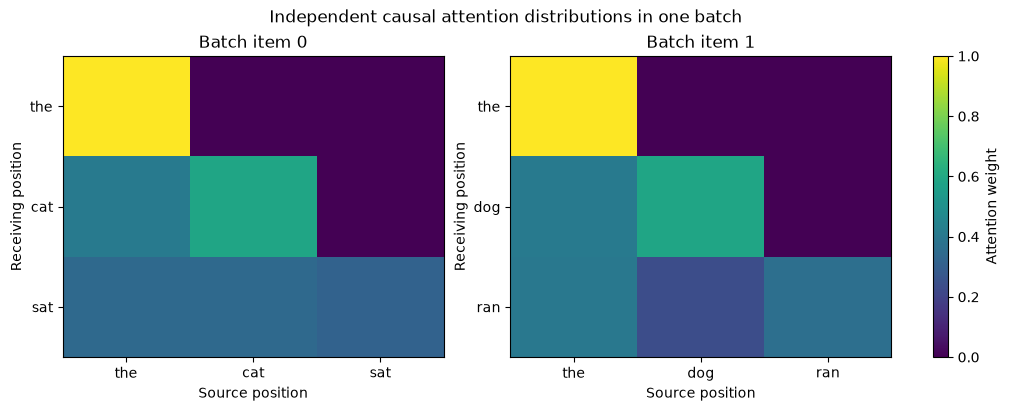

In [11]:
import matplotlib.pyplot as plt

figure, axes = plt.subplots(1, batch_size, figsize=(10, 4), constrained_layout=True)
for batch_index, axis in enumerate(axes):
    image = axis.imshow(
        attention_weights[batch_index].detach(),
        aspect="auto",
        vmin=0.0,
        vmax=1.0,
    )
    axis.set_xticks(range(context_length), batch_tokens[batch_index])
    axis.set_yticks(range(context_length), batch_tokens[batch_index])
    axis.set_xlabel("Source position")
    axis.set_ylabel("Receiving position")
    axis.set_title(f"Batch item {batch_index}")

figure.colorbar(image, ax=axes, label="Attention weight")
figure.suptitle("Independent causal attention distributions in one batch")
plt.show()

Both tables have zeros above the diagonal because they share the positional mask.

Their allowed weights differ because each sequence produces its own queries and keys.


## Shape summary

| Tensor | Shape | Meaning |
|---|---:|---|
| Input | `B × T × C` | `B` sequences, `T` positions, `C` input features |
| Queries and keys | `B × T × D` | `D` query-key features per position |
| Values | `B × T × V` | `V` value features per position |
| Scores and weights | `B × T × T` | one receiving-by-source table per batch item |
| Explicit causal mask | `1 × T × T` | one positional rule broadcast across `B` |
| Output | `B × T × V` | one value mixture per position per batch item |

The batch axis remains a leading grouping axis throughout the calculation.

Only the two final dimensions participate in attention matrix multiplication.


## Common mistakes

- **Treating the batch as one sequence:** batch items are independent examples, not adjacent context segments.

- **Transposing a batch axis:** use `transpose(-2, -1)` to swap only context and feature axes.

- **Applying softmax over batches:** use `dim=-1` so each receiving position distributes weight across source positions.

- **Putting the singleton mask dimension last:** `[T, T, 1]` does not label the intended batch axis.

- **Expanding the mask manually when unnecessary:** `[1, T, T]` can broadcast directly during `masked_fill`.

- **Ignoring padding:** causal masking blocks future positions but does not hide padded tokens in variable-length batches.

- **Dropping the context axis:** batched self-attention returns one output vector per position in every batch item.


## Takeaways

- Batched input has shape `[batch, context, embedding]`.

- Shared projections transform each batch item independently.

- `queries @ keys.transpose(-2, -1)` creates one score table per batch item.

- A Boolean mask shaped `[1, context, context]` expresses one causal rule broadcast across the batch.

- Softmax uses the final source-position axis, never the batch axis.

- Batched and separately computed outputs are identical.

- Changing one sequence cannot affect another sequence's attention result.

> The batch dimension enables parallel computation without creating cross-sequence attention.


## What comes next

This chapter added one leading batch axis while keeping one attention head.

The next chapter adds a head axis so several attention patterns can be computed in parallel for every sequence in every batch.
